In [1]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()
# converts the image into a pytorch tensor
# and a pixel value is [0,255] this scales it down to [0,1]

mnist = datasets.MNIST(
    root=str(ROOT / 'data'),
    train=True, # loading training split , will get Test data if set to False
    download=True,
    transform=transform #
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.28MB/s]


In [3]:
img, label = mnist[0]

print(type(img))
print(img.shape) # C H W as MNIST is channel first, C=1 as grayscale images
print(label)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])
5


In [4]:
for i in range(16):
    _, label = mnist[i]
    print(f"Image {i}: Label = {label}")

Image 0: Label = 5
Image 1: Label = 0
Image 2: Label = 4
Image 3: Label = 1
Image 4: Label = 9
Image 5: Label = 2
Image 6: Label = 1
Image 7: Label = 3
Image 8: Label = 1
Image 9: Label = 4
Image 10: Label = 3
Image 11: Label = 5
Image 12: Label = 3
Image 13: Label = 6
Image 14: Label = 1
Image 15: Label = 7


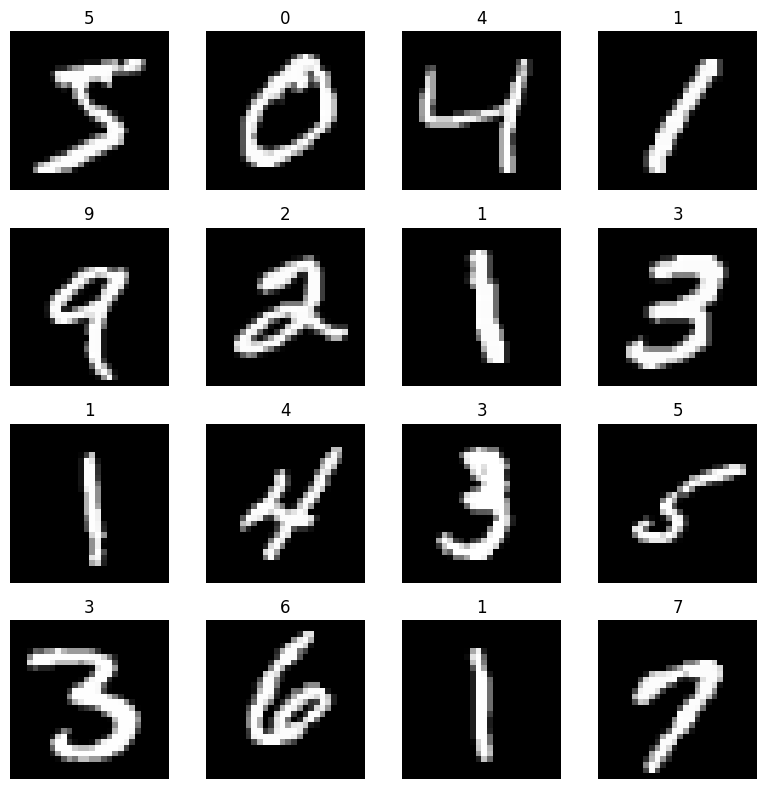

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i in range(16):
    img, label = mnist[i]

    axes[i//4, i%4].imshow(img.squeeze(), cmap='gray')
    axes[i//4, i%4].set_title(f"{label}")
    axes[i//4, i%4].axis('off')

plt.tight_layout()
plt.show()

# squeeze
# currently shape is 1 28 28
# but matplotlib wants 28 28
# so squeeze removes the 1

In [6]:
print(img.shape)

print(img[0].shape)

torch.Size([1, 28, 28])
torch.Size([28, 28])


In [7]:
print(img.mean())

tensor(0.1265)


In [8]:
print(img.min())
print(img.max())

tensor(0.)
tensor(1.)


The minimum pixel value is 0 and the maximum pixel value is approximately 1, showing that ToTensor() has normalized the original pixel intensities from the range [0,255] to [0,1]. Each tensor element represents the brightness of a pixel, where 0 corresponds to black and 1 corresponds to white.

In [9]:
img, label = mnist[0]

flat_img = img.view(-1) # this is like saying :
# Reshape this tensor into a 1D vector. Figure out the length automatically

print("Original shape:", img.shape)
print("Flattened shape:", flat_img.shape)

Original shape: torch.Size([1, 28, 28])
Flattened shape: torch.Size([784])


The original MNIST image has shape (1, 28, 28). After flattening using view(-1), it becomes a one-dimensional vector of shape (784,). Each element of the vector represents the intensity of one pixel in the image.

torch.Size([1, 28, 28])


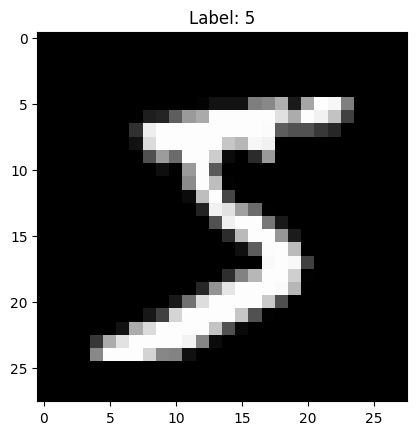

In [10]:
reconstructed = flat_img.view(1, 28, 28)

print(reconstructed.shape)

plt.imshow(reconstructed.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [11]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

cifar = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=True,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [00:03<00:00, 45.2MB/s]


In [12]:
print(len(cifar))

50000


In [13]:
img, label = cifar[0]

print(type(img))
print(img.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6


In [14]:
print(cifar.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [15]:
print(cifar.classes[label])

frog


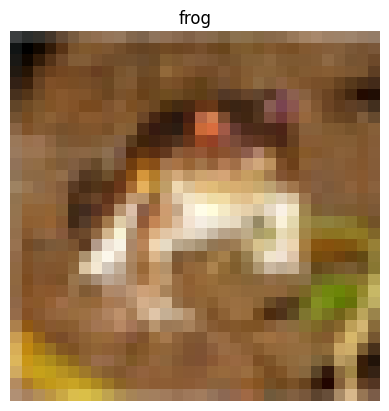

In [16]:
plt.imshow(img.permute(1, 2, 0)) # changes C H W to H W C
plt.title(cifar.classes[label])
plt.axis('off')
plt.show()

In [17]:
img[0].shape

torch.Size([32, 32])

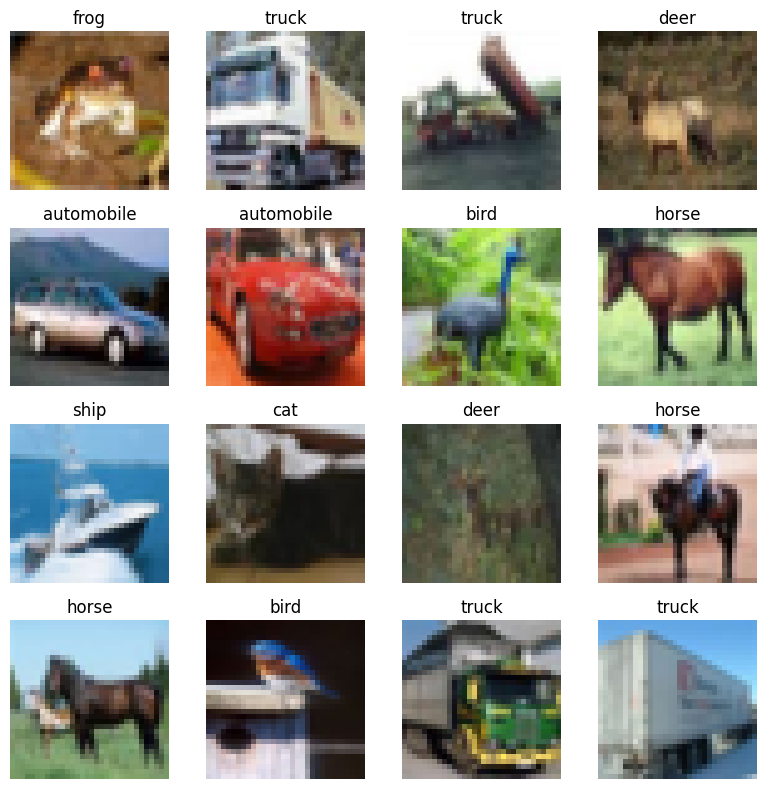

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i in range(16):
    img, label = cifar[i]

    axes[i//4, i%4].imshow(img.permute(1, 2, 0))
    axes[i//4, i%4].set_title(cifar.classes[label])
    axes[i//4, i%4].axis('off')

plt.tight_layout()
plt.show()

In [19]:
from torch.utils.data import DataLoader

loader = DataLoader(
    cifar,
    batch_size=64,
    shuffle=True
)

In [20]:
x, y = next(iter(loader))

print(x.shape)
print(y.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])
